In [1]:
import numpy as np
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [17]:
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
BASE_PATH = "/kaggle/input/playground-series-s5e10"
TRAIN_FILE = os.path.join(BASE_PATH, "train.csv")
TEST_FILE = os.path.join(BASE_PATH, "test.csv")


In [14]:
target = "accident_risk"

In [74]:
DEFAULT_SELECTED_COLS = ["road_type", "num_lanes", "speed_limit", "lighting", "weather", "road_signs_present", "public_road", "time_of_day", "holiday", "school_season"]

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
train_data = pd.read_csv(TRAIN_FILE)
train_data.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [8]:
train_data.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

In [28]:
train_data.loc[train_data[target] > 0.5, "high_chance"] = True
train_data.loc[train_data[target] <= 0.5, "high_chance"] = False

In [29]:
train_data.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,road_type_enc,high_chance
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,2,False
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,2,False
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,1,False
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,0,False
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,1,True


In [44]:
train_data['high_chance'] = train_data['high_chance'].astype(bool)
train_data['high_chance'].dtype

dtype('bool')

In [51]:
true_rows = train_data[train_data["high_chance"] == True]
false_rows = train_data[train_data["high_chance"] == False]

In [61]:
def plot_counting(data,selected_cols=DEFAULT_SELECTED_COLS):
    cols = 4
    n_selected_cols = len(selected_cols)
    rows = int(np.ceil(n_selected_cols/cols))
    
    fig,ax = plt.subplots(rows, cols, figsize=(30,15))
    
    current_selected_col = 0
    for i in range(rows):
        for j in range(cols):
            if(current_selected_col >= n_selected_cols):
                continue
            
            sns.countplot(data=data, x=selected_cols[current_selected_col], ax=ax[i,j])
            current_selected_col += 1
    
    plt.show()

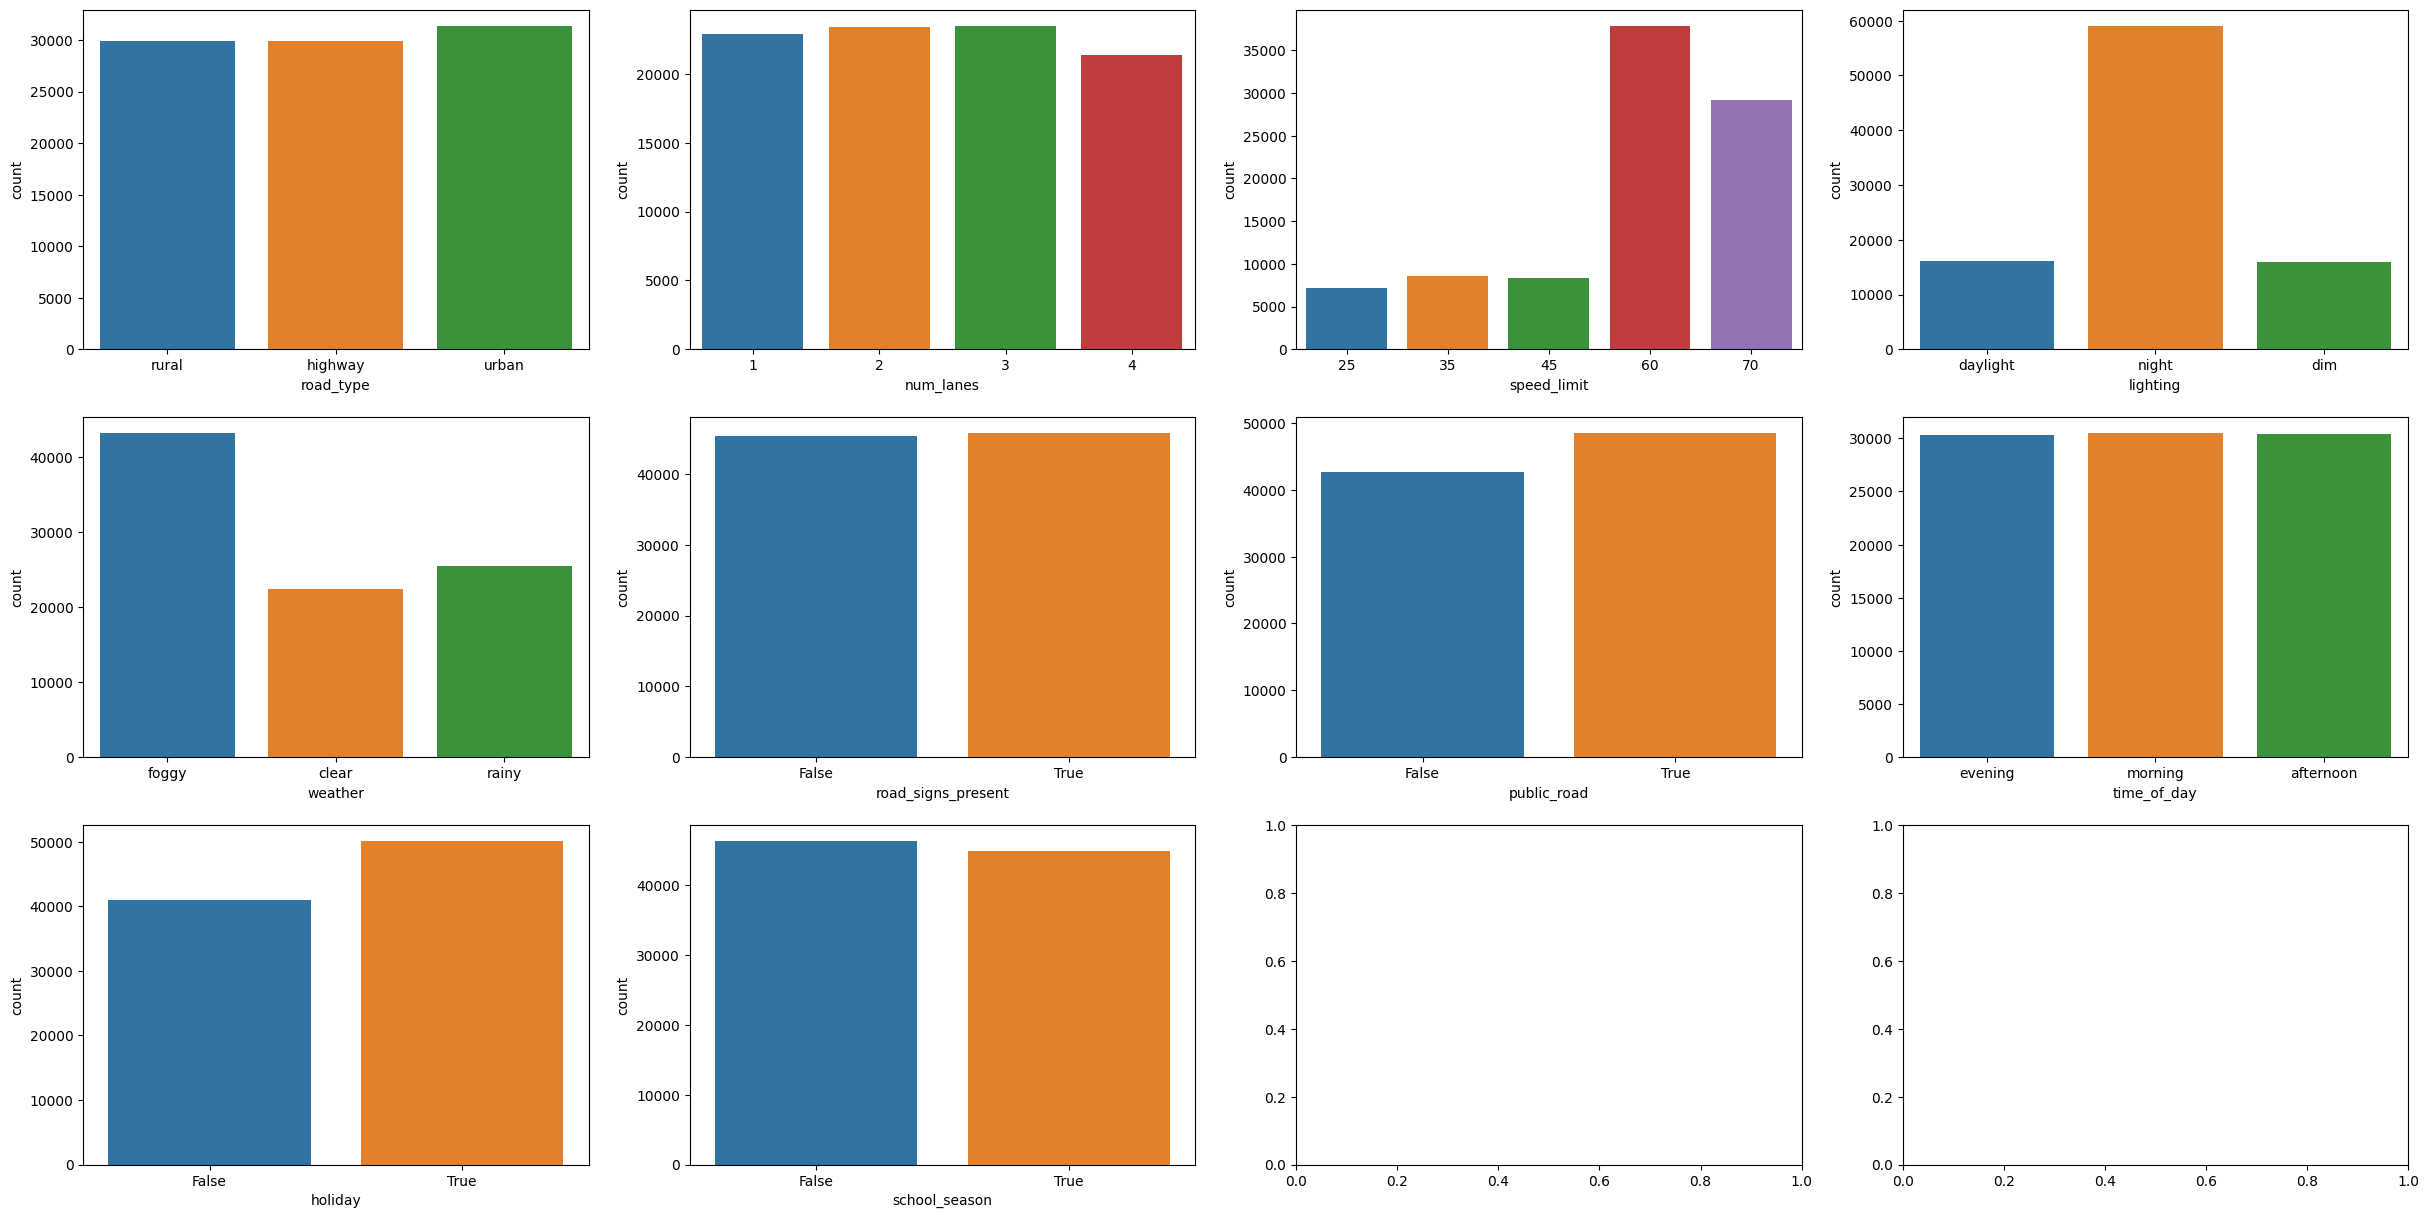

In [62]:
plot_counting(true_rows)

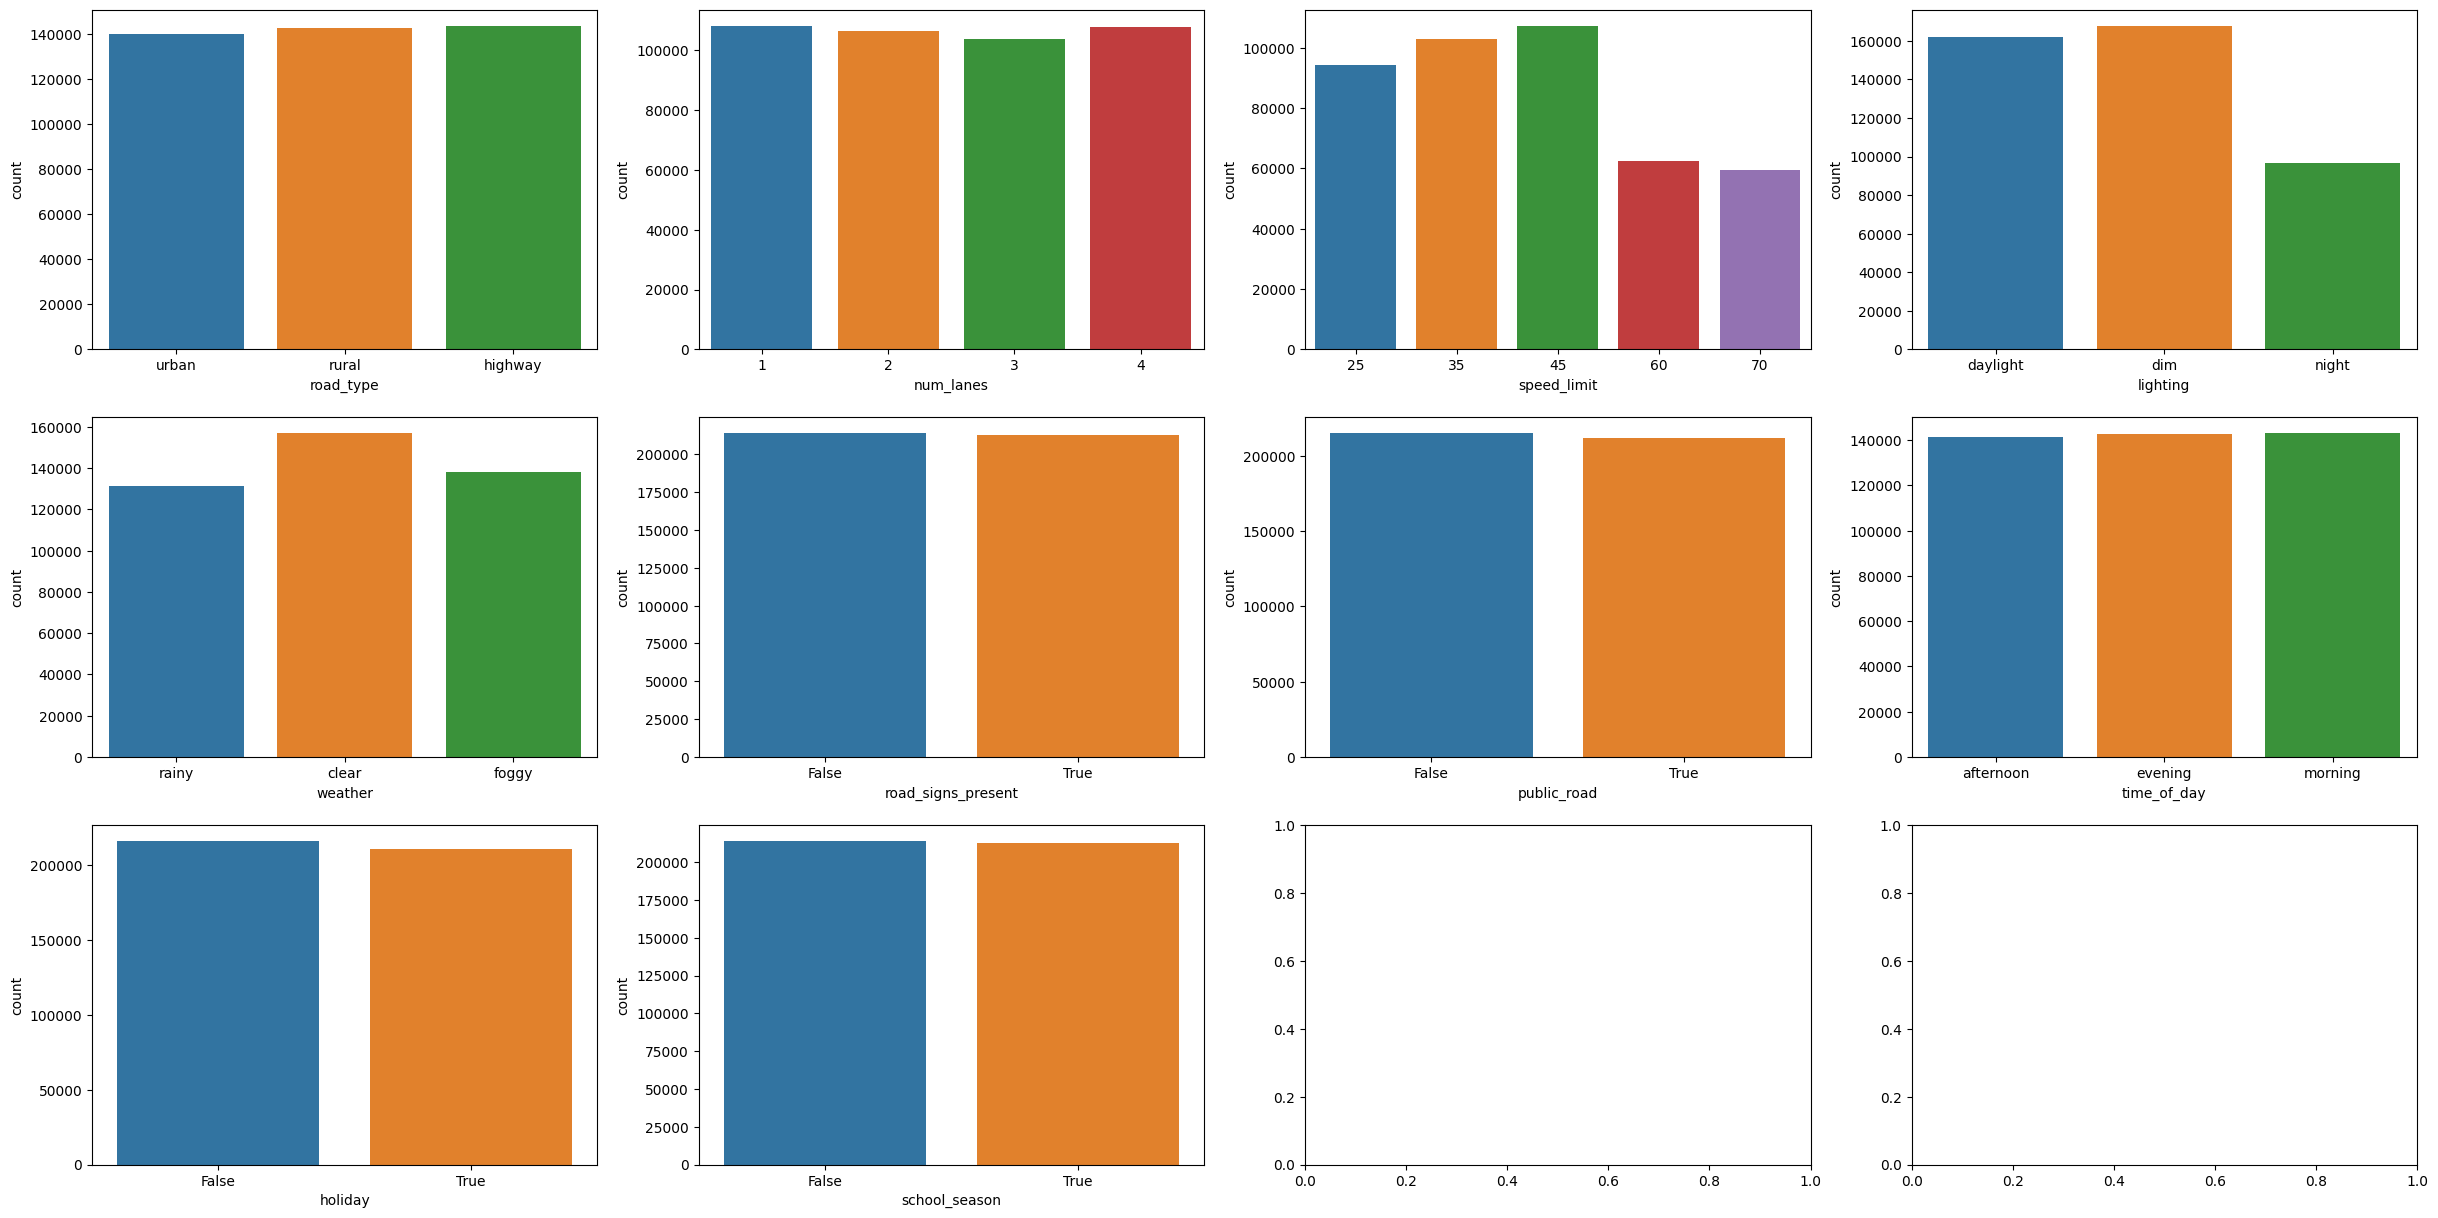

In [63]:
plot_counting(false_rows)

In [75]:
def plot_dist(data, selected_cols=DEFAULT_SELECTED_COLS, target_col=target):
    cols = 4
    n_selected_cols = len(selected_cols)
    rows = int(np.ceil(n_selected_cols/cols))
    
    fig,ax = plt.subplots(rows, cols, figsize=(30,15))
    
    current_selected_col = 0
    for i in range(rows):
        for j in range(cols):
            if(current_selected_col >= n_selected_cols):
                continue
            
            sns.histplot(data=data, x=target_col, hue=selected_cols[current_selected_col], ax=ax[i,j], kde=True)
            current_selected_col += 1
    
    plt.show()

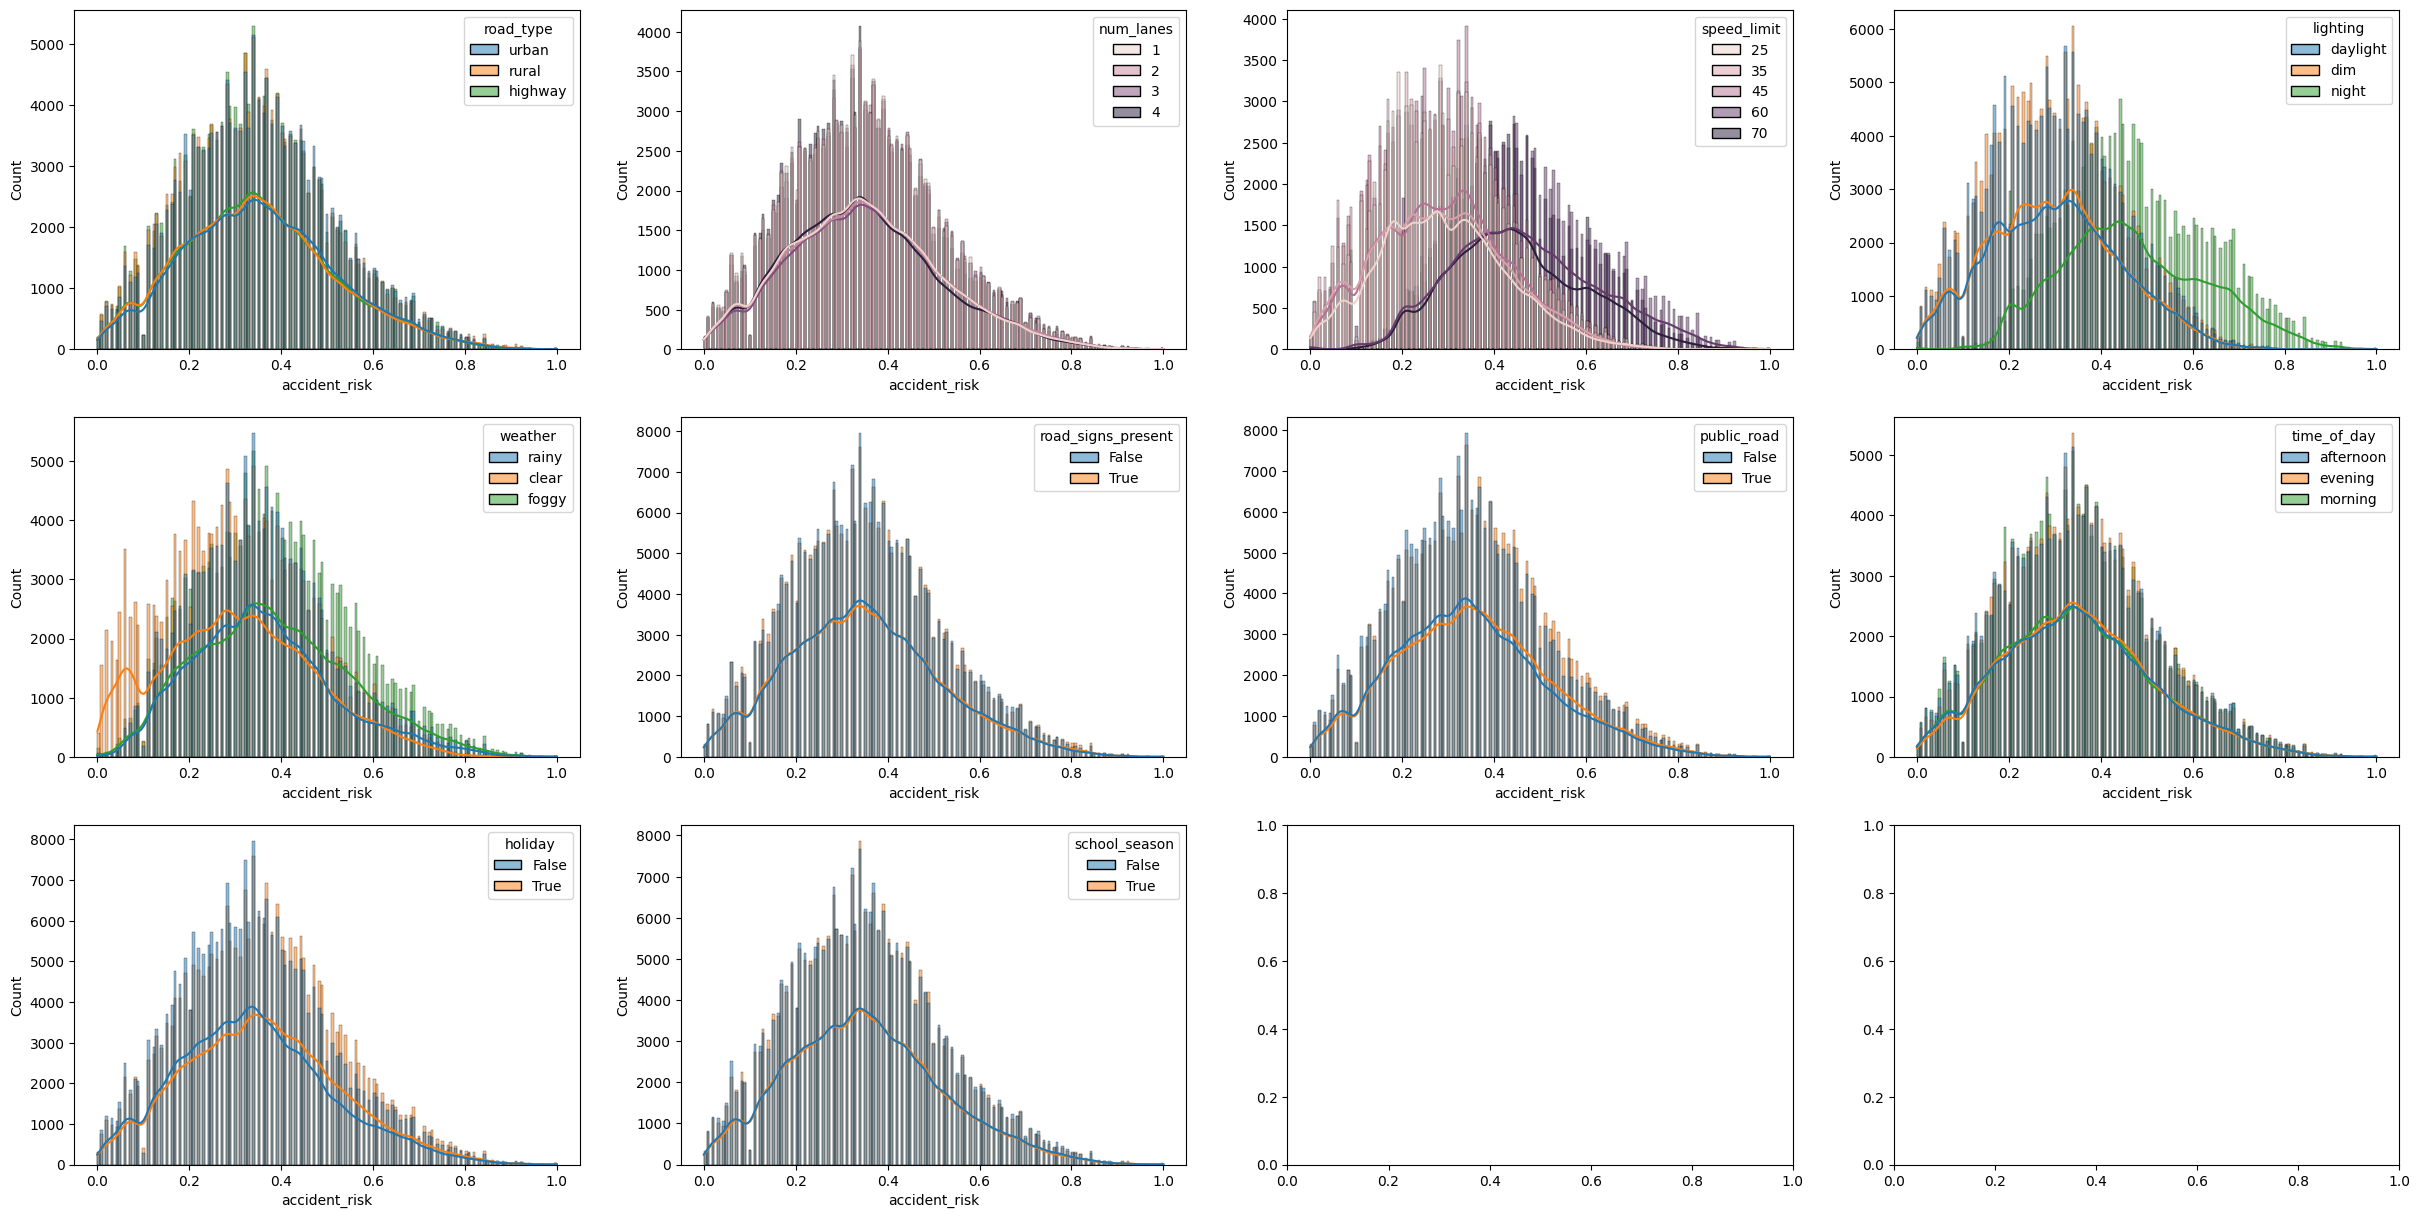

In [76]:
plot_dist(train_data)

[]

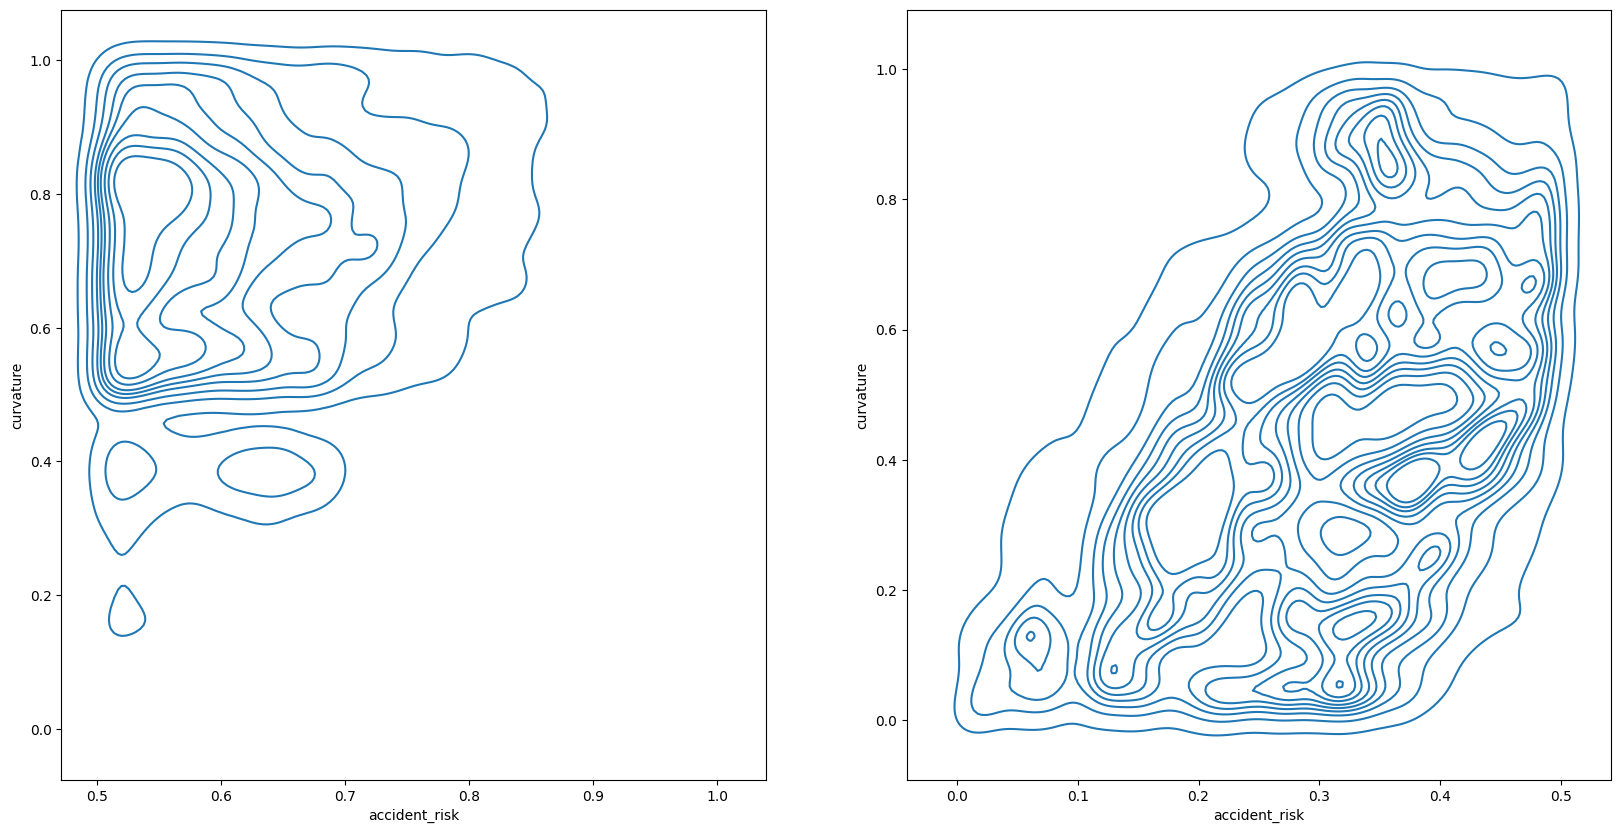

In [86]:
fig,ax=plt.subplots(1,2, figsize=(20,10))
sns.kdeplot(data=true_rows, x=target, y="curvature",ax=ax[0])
sns.kdeplot(data=false_rows, x=target, y="curvature",ax=ax[1])
plt.plot()

In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

In [115]:
enc = OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')

In [116]:
features = ["speed_limit", "lighting", "weather"]
categorial_features = features[1:]

In [120]:
enc.fit(train_data[categorial_features])
results = enc.transform(train_data[categorial_features])
results

array([[0., 0., 0., 1.],
       [0., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 1.]])

In [122]:
one_hot_encoded_df = pd.DataFrame(results, columns=enc.get_feature_names_out(categorial_features))
one_hot_encoded_df.head()

,lighting_dim,lighting_night,weather_foggy,weather_rainy
0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0


In [124]:
X = pd.concat([one_hot_encoded_df, train_data[features[0]]], ignore_index=True)
X.head()

,lighting_dim,lighting_night,weather_foggy,weather_rainy,0
0,0.0,0.0,0.0,1.0,NaN
1,0.0,0.0,0.0,0.0,NaN
2,1.0,0.0,0.0,0.0,NaN
3,1.0,0.0,0.0,1.0,NaN
4,0.0,0.0,1.0,0.0,NaN


In [89]:
model = LinearRegression()


model.fit(X,y)

ValueError: could not convert string to float: 'daylight'